# 🔍 Домашнее задание: Поиск изображений по тексту (Track A)

## 📚 Цель работы
Строим систему **text-to-image retrieval**: по текстовому запросу («собака на пляже», «красный автомобиль») находим наиболее релевантные изображения из корпуса. Для этого изображения и текст проецируются в одно векторное пространство мультимодальной моделью **CLIP**, после чего поиск сводится к поиску ближайших соседей по косинусной близости.

## 🗂️ Датасет
[**Visual Genome**](https://huggingface.co/datasets/nirmalendu01/visual_genome) — 108K изображений с плотными аннотациями: каждая картинка размечена десятками текстовых описаний отдельных регионов (`region_descriptions`). Используем parquet-зеркало датасета (шарды по строкам вместо ZIP-архивов изображений у оригинала — см. пояснение в части 1.1), которое грузится в **streaming**-режиме прямо с HuggingFace Hub, без предварительного скачивания архивов — берём первые **~5 000 изображений**.

Для каждого изображения в качестве «эталонной» подписи берём самое длинное (обычно самое информативное) региональное описание — это даёт естественный набор `(изображение, релевантный текст)` для последующей оценки качества поиска.

## 🧠 Модели
- **CLIP** (`openai/clip-vit-base-patch32`) — основная модель: кодирует изображения и текст в общее 512-мерное пространство. Инференс выполняется **локально на CPU** (модель компактная, ~150 МБ, инференс на 5К изображений занимает разумное время; GPU в системе — Quadro P2000 4GB/Pascal, но для честности и воспроизводимости эмбеддинги считаем на CPU).
- **SentenceTransformers** (`all-MiniLM-L6-v2`) — baseline для сравнения: этот энкодер умеет работать только с текстом, поэтому используется в схеме *text-to-text* (запрос сравнивается с текстами подписей, а не с самими изображениями напрямую). Это позволяет наглядно показать разницу между «настоящим» мультимодальным поиском и косвенным текстовым сопоставлением через подписи.

## 📝 Структура работы
1. **Подготовка данных** — загрузка Visual Genome, отбор подписей, предобработка изображений.
2. **Создание индекса** — вычисление CLIP-эмбеддингов, построение векторного индекса FAISS.
3. **Реализация поиска** — функция text-to-image поиска, ранжирование, замер времени запроса.
4. **Оценка и анализ** — тестовые запросы, метрики (Recall@K, MRR), сравнение CLIP vs SentenceTransformers baseline.

> ⚠️ Первый запуск требует скачивания шардов Visual Genome (~несколько ГБ трафика) и весов CLIP/MiniLM — учитывайте это перед полным прогоном ноутбука.

## 📦 Часть 0: Установка и импорт библиотек

In [1]:
# Установка необходимых библиотек (если требуется)
# !pip install torch transformers datasets sentence-transformers faiss-cpu pillow matplotlib numpy tqdm

import os
import sys
import asyncio
import time
import random
import warnings
warnings.filterwarnings('ignore')

# На Windows датасеты в streaming-режиме (fsspec/aiohttp поверх ZIP-архивов, как у Visual
# Genome) зависают под стандартным Proactor event loop -- переключаемся на Selector,
# как и рекомендует предупреждение aiohttp/zmq при импорте datasets.
if sys.platform == 'win32':
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

from datasets import load_dataset
from transformers import CLIPModel, CLIPProcessor
from sentence_transformers import SentenceTransformer
import faiss

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Считаем эмбеддинги на CPU (см. пояснение в шапке ноутбука про GPU Pascal/CLIP)
DEVICE = 'cpu'
print(f'device = {DEVICE}')
print(f'torch {torch.__version__}')

device = cpu
torch 2.12.1+cpu


## 📥 Часть 1: Подготовка данных

### 1.1 Загрузка Visual Genome (streaming)

Используем `streaming=True`, чтобы не скачивать датасет целиком. Берём parquet-зеркало [`nirmalendu01/visual_genome`](https://huggingface.co/datasets/nirmalendu01/visual_genome) вместо оригинального `ranjaykrishna/visual_genome`: у оригинала loading-скрипт даже в streaming-режиме тянет ZIP-архивы изображений (~10 ГБ) целиком с серверов Stanford и читает их central directory по HTTP range-запросам — на практике это крайне медленно и нестабильно (единицы минут на одно изображение, разрывы соединения). Parquet-зеркало хранит те же данные (изображения + аннотации Visual Genome) шардами по строкам — streaming читает их построчно и на порядки быстрее.

Для каждого изображения:
- сохраняем уменьшенную копию (для скорости эмбеддинга и компактного хранения превью в индексе);
- в качестве эталонной подписи берём самое длинное описание из `region_descriptions` — как правило оно наиболее информативно описывает сцену целиком, а не мелкую деталь.

In [2]:
N_IMAGES = 5000          # сколько изображений взять из потока Visual Genome
THUMB_SIZE = (256, 256)  # уменьшенная копия для индекса/превью
MIN_PHRASE_LEN = 15      # отсекаем совсем короткие/неинформативные region-подписи

vg_stream = load_dataset(
    'nirmalendu01/visual_genome',
    split='train',
    streaming=True,
)

records = []  # [{'image_id', 'image', 'caption'}]
t0 = time.time()

for example in tqdm(vg_stream, total=N_IMAGES, desc='Скачивание Visual Genome (streaming)'):
    regions = [p for p in example['region_descriptions'] if len(p) >= MIN_PHRASE_LEN]
    if not regions:
        continue
    caption = max(regions, key=len)

    img = example['image'].convert('RGB')
    img.thumbnail(THUMB_SIZE)  # уменьшаем на месте, сохраняя пропорции

    records.append({
        'image_id': example['id'],
        'image': img,
        'caption': caption,
    })

    if len(records) >= N_IMAGES:
        break

print(f'Загружено {len(records)} изображений за {time.time() - t0:.1f} сек')

Resolving data files:   0%|          | 0/32 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/32 [00:00<?, ?it/s]

Скачивание Visual Genome (streaming):   0%|          | 0/5000 [00:00<?, ?it/s]

Загружено 5000 изображений за 517.3 сек


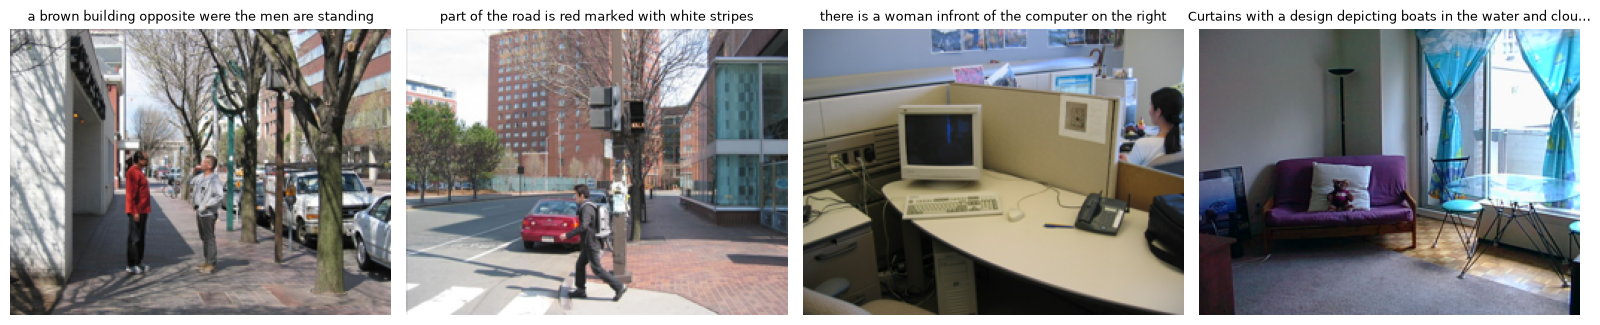

Средняя длина подписи: 8.5 слов (мин 4, макс 21)


In [3]:
# Быстрый взгляд на данные: пара примеров изображение + подпись
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, rec in zip(axes, records[:4]):
    ax.imshow(rec['image'])
    ax.set_title(rec['caption'][:60] + ('…' if len(rec['caption']) > 60 else ''), fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

caption_lens = [len(r['caption'].split()) for r in records]
print(f'Средняя длина подписи: {np.mean(caption_lens):.1f} слов (мин {min(caption_lens)}, макс {max(caption_lens)})')

## 🧩 Часть 2: Создание мультимодальных эмбеддингов и индекса

### 2.1 Загрузка CLIP и вычисление эмбеддингов изображений

`CLIPModel` кодирует изображения и текст в общее 512-мерное пространство (`openai/clip-vit-base-patch32`). Эмбеддинги нормализуем по L2 — тогда скалярное произведение совпадает с косинусной близостью, что удобно для FAISS (`IndexFlatIP`).

In [4]:
CLIP_MODEL_NAME = 'openai/clip-vit-base-patch32'

clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(DEVICE).eval()
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)

EMBED_DIM = clip_model.config.projection_dim
print(f'CLIP загружен, размерность эмбеддинга = {EMBED_DIM}')


@torch.no_grad()
def clip_encode_images(images, batch_size=32):
    """Кодирует список PIL.Image в L2-нормализованные CLIP-эмбеддинги (N, EMBED_DIM)."""
    all_embeds = []
    for i in tqdm(range(0, len(images), batch_size), desc='CLIP: эмбеддинги изображений'):
        batch = images[i:i + batch_size]
        inputs = clip_processor(images=batch, return_tensors='pt').to(DEVICE)
        feats = clip_model.get_image_features(**inputs)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        all_embeds.append(feats.cpu().numpy())
    return np.concatenate(all_embeds, axis=0).astype('float32')


@torch.no_grad()
def clip_encode_text(texts, batch_size=64):
    """Кодирует список строк в L2-нормализованные CLIP-эмбеддинги (N, EMBED_DIM)."""
    all_embeds = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        inputs = clip_processor(text=batch, return_tensors='pt', padding=True, truncation=True).to(DEVICE)
        feats = clip_model.get_text_features(**inputs)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        all_embeds.append(feats.cpu().numpy())
    return np.concatenate(all_embeds, axis=0).astype('float32')

CLIP загружен, размерность эмбеддинга = 512


In [5]:
images = [r['image'] for r in records]
captions = [r['caption'] for r in records]
image_ids = [r['image_id'] for r in records]

t0 = time.time()
image_embeddings = clip_encode_images(images)
print(f'image_embeddings: {image_embeddings.shape}, {time.time() - t0:.1f} сек')

CLIP: эмбеддинги изображений:   0%|          | 0/157 [00:00<?, ?it/s]

'HTTPSConnectionPool(host='us.aws.cdn.hf.co', port=443): Read timed out.' thrown while requesting GET https://huggingface.co/datasets/nirmalendu01/visual_genome/resolve/1b2590f06f61aaf9b3bf1b29bc997ed8f0fbfe3d/data/train-00001-of-00032.parquet
Retrying in 1s [Retry 1/5].


image_embeddings: (5000, 512), 314.1 сек


### 2.2 Построение векторного индекса FAISS

Берём `IndexFlatIP` (inner product = cosine similarity на нормализованных векторах) — точный (не приближённый) поиск, что для 5К изображений выполняется за миллисекунды и даёт эталонное качество без потерь от приближённых методов (HNSW/IVF имеет смысл только на десятках-сотнях тысяч+ векторов).

In [6]:
clip_index = faiss.IndexFlatIP(EMBED_DIM)
clip_index.add(image_embeddings)
print(f'FAISS индекс построен: {clip_index.ntotal} векторов, размерность {clip_index.d}')

FAISS индекс построен: 5000 векторов, размерность 512


## 🔎 Часть 3: Реализация поиска

### 3.1 Text-to-image поиск через CLIP

Запрос кодируется тем же CLIP text-encoder'ом и ищется по FAISS индексу изображений. Функция возвращает top-K изображений с их similarity-score.

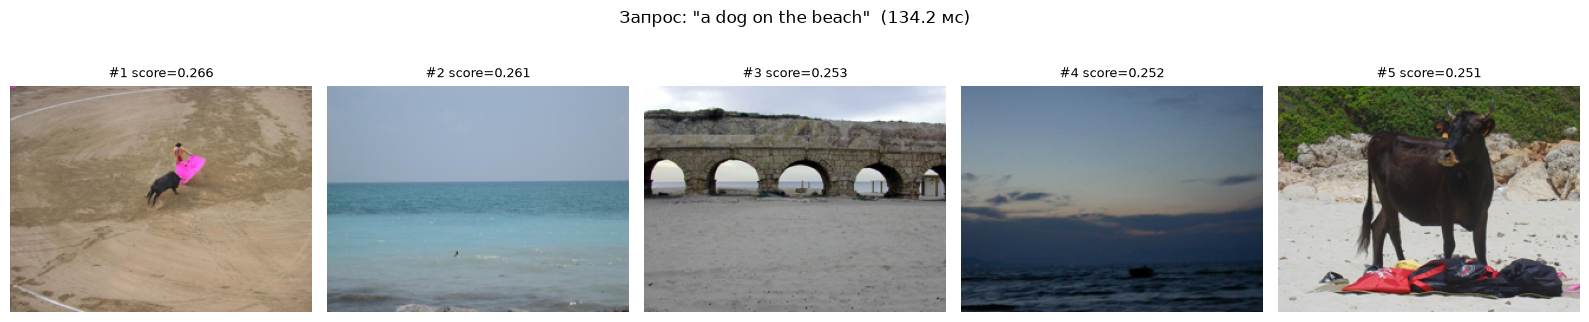

#1  score=0.266  caption="A chalk line used to set boundaries in the bull fighting ring."
#2  score=0.261  caption="the object sticking out of the water"
#3  score=0.253  caption="Some grass and vegetation growing on top of arches."
#4  score=0.252  caption="dark grey cloud floating in the sky"
#5  score=0.251  caption="green vegetation is on the background"


In [7]:
def search_clip(query, top_k=5):
    """Text-to-image поиск: запрос -> CLIP text embedding -> FAISS nearest neighbors."""
    t0 = time.time()
    query_emb = clip_encode_text([query])
    scores, indices = clip_index.search(query_emb, top_k)
    elapsed_ms = (time.time() - t0) * 1000

    results = [
        {
            'rank': rank + 1,
            'index': int(idx),
            'image_id': image_ids[idx],
            'caption': captions[idx],
            'score': float(score),
        }
        for rank, (idx, score) in enumerate(zip(indices[0], scores[0]))
    ]
    return results, elapsed_ms


def show_search_results(query, results, elapsed_ms, ncols=5):
    fig, axes = plt.subplots(1, len(results), figsize=(3.2 * len(results), 3.6))
    if len(results) == 1:
        axes = [axes]
    for ax, res in zip(axes, results):
        ax.imshow(images[res['index']])
        ax.set_title(f"#{res['rank']} score={res['score']:.3f}", fontsize=9)
        ax.axis('off')
    fig.suptitle(f'Запрос: "{query}"  ({elapsed_ms:.1f} мс)', fontsize=12)
    plt.tight_layout()
    plt.show()


# Пробный запрос
demo_query = 'a dog on the beach'
demo_results, demo_ms = search_clip(demo_query, top_k=5)
show_search_results(demo_query, demo_results, demo_ms)
for r in demo_results:
    print(f"#{r['rank']}  score={r['score']:.3f}  caption=\"{r['caption'][:80]}\"")

### 3.2 Примеры запросов из задания

> Датасет и CLIP (`openai/clip-vit-base-patch32`) — англоязычные, поэтому запросы приведены на английском (аналоги «собака на пляже», «красный автомобиль», «люди играют в футбол»); ниже также показан пример с русским запросом для сравнения качества.

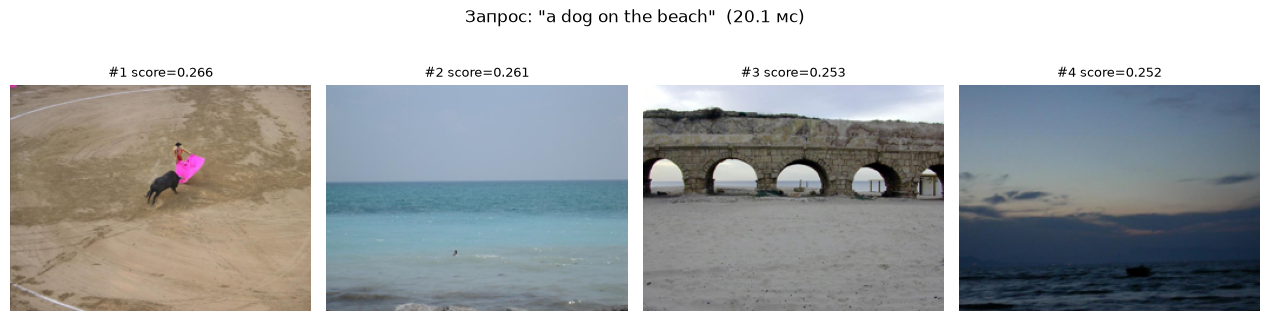

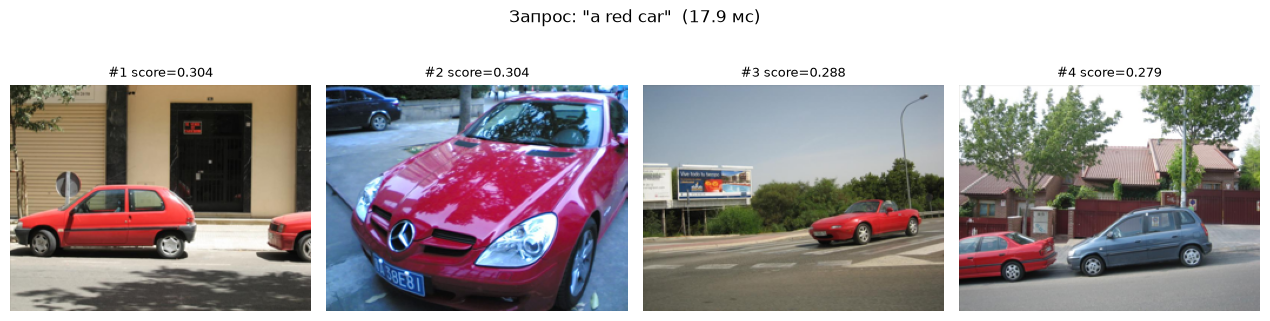

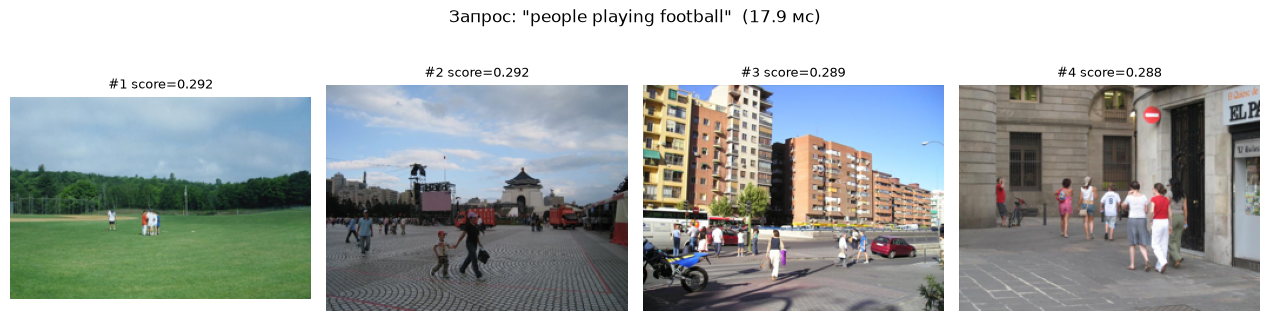

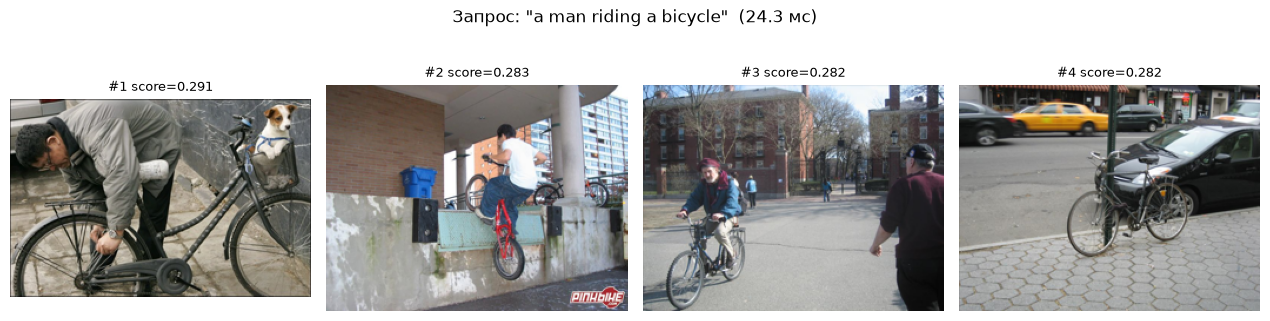

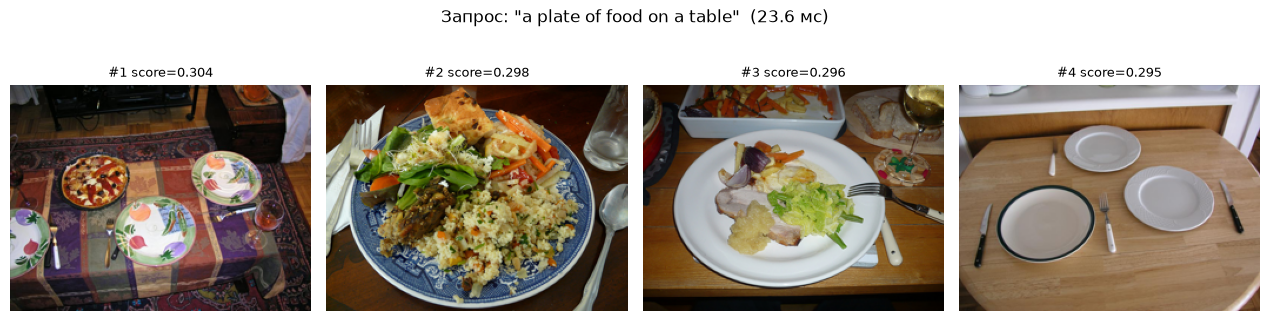

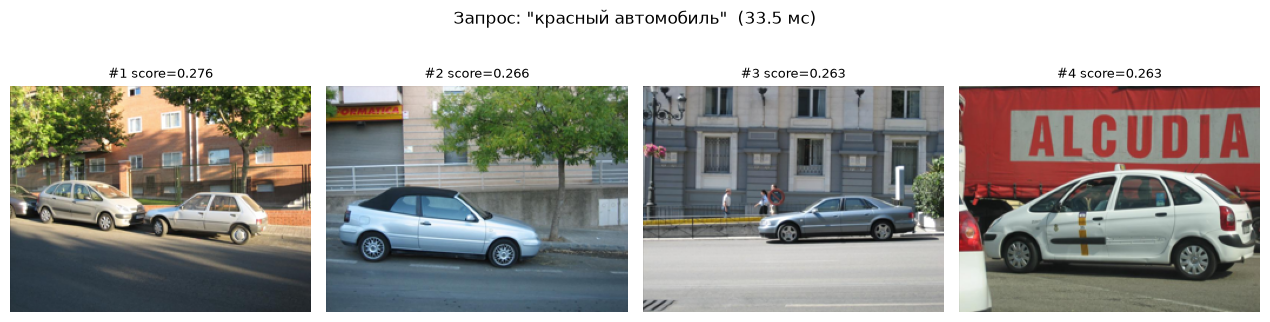

In [8]:
example_queries = [
    'a dog on the beach',        # собака на пляже
    'a red car',                  # красный автомобиль
    'people playing football',    # люди играют в футбол
    'a man riding a bicycle',
    'a plate of food on a table',
]

for q in example_queries:
    res, ms = search_clip(q, top_k=4)
    show_search_results(q, res, ms)

# Пример на русском — CLIP видел мало русскоязычного текста при обучении,
# поэтому качество на русских запросах обычно заметно хуже
ru_query = 'красный автомобиль'
res_ru, ms_ru = search_clip(ru_query, top_k=4)
show_search_results(ru_query, res_ru, ms_ru)

### 3.3 Baseline: SentenceTransformers (text-to-text через подписи)

`all-MiniLM-L6-v2` не умеет кодировать изображения — поэтому этот baseline ищет ближайшую по смыслу **подпись**, а изображение возвращает как «приложенное» к найденной подписи. Это принципиально иная и более слабая схема: если у изображения нет близкой по формулировке текстовой подписи в корпусе, оно не будет найдено, даже если визуально идеально подходит под запрос. Сравнение с CLIP наглядно показывает преимущество истинно мультимодального эмбеддинга.

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

caption_embeddings: (5000, 384), 10.0 сек


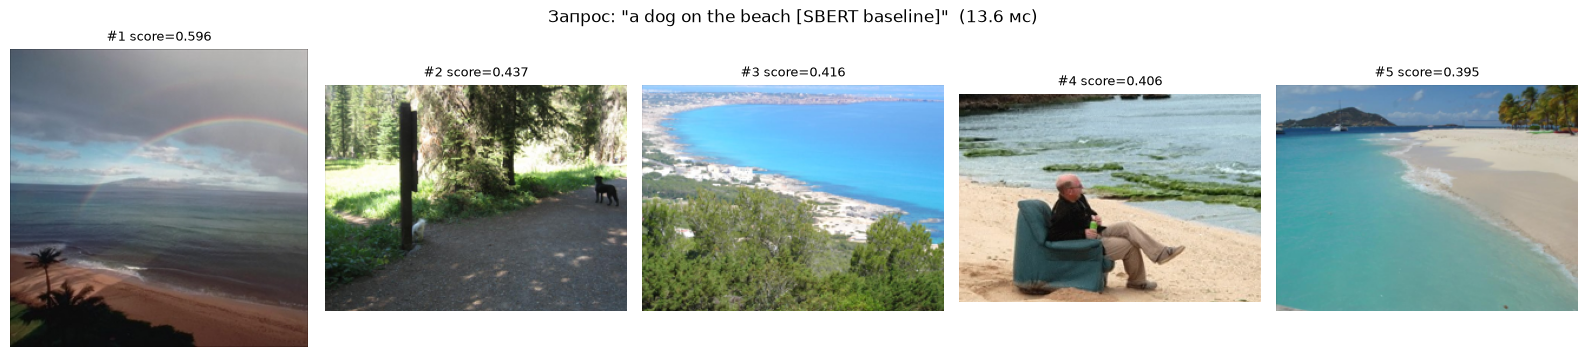

In [9]:
st_model = SentenceTransformer('all-MiniLM-L6-v2', device=DEVICE)

t0 = time.time()
caption_embeddings = st_model.encode(
    captions, batch_size=64, show_progress_bar=True, normalize_embeddings=True,
).astype('float32')
print(f'caption_embeddings: {caption_embeddings.shape}, {time.time() - t0:.1f} сек')

st_index = faiss.IndexFlatIP(caption_embeddings.shape[1])
st_index.add(caption_embeddings)


def search_sbert(query, top_k=5):
    """Text-to-text поиск: запрос сравнивается с подписями (не с самими изображениями)."""
    t0 = time.time()
    query_emb = st_model.encode([query], normalize_embeddings=True).astype('float32')
    scores, indices = st_index.search(query_emb, top_k)
    elapsed_ms = (time.time() - t0) * 1000

    results = [
        {
            'rank': rank + 1,
            'index': int(idx),
            'image_id': image_ids[idx],
            'caption': captions[idx],
            'score': float(score),
        }
        for rank, (idx, score) in enumerate(zip(indices[0], scores[0]))
    ]
    return results, elapsed_ms


demo_results_sbert, demo_ms_sbert = search_sbert(demo_query, top_k=5)
show_search_results(demo_query + ' [SBERT baseline]', demo_results_sbert, demo_ms_sbert)

## 📈 Часть 4: Оценка и анализ

### 4.1 Методика

Для количественной оценки используем сами подписи Visual Genome как тестовые запросы: подпись `caption[i]` была взята из региона изображения `image[i]`, значит **gold-релевантным** для этого запроса считается именно изображение `i`. Это стандартный приём при отсутствии ручной разметки relevance (аналогично тому, как строится evaluation для Flickr30K/COCO retrieval).

На случайной подвыборке из `EVAL_SIZE` подписей считаем:
- **Recall@K** — доля запросов, для которых gold-изображение попало в top-K выдачи;
- **MRR (Mean Reciprocal Rank)** — среднее от `1 / rank_gold` (устойчивее к «где именно» в топе нашёлся ответ).

Сравниваем CLIP (настоящий text→image поиск) и SBERT-baseline (text→text по подписям, см. 3.3).

> ⚠️ **Важная оговорка про Visual Genome конкретно.** В отличие от Flickr30K/COCO, где подпись описывает *всё* изображение целиком, подписи Visual Genome — это **region descriptions**: короткие фразы про отдельную деталь сцены («dark grey cloud floating in the sky», «green vegetation is on the background»). Из-за этого self-retrieval здесь смещён в пользу SBERT: SBERT ищет точное текстовое совпадение (query — это буквально та же строка, что и caption в индексе), поэтому его recall@1 будет близок к 1.0 почти по определению — это measures text-matching, не понимание изображения. CLIP же ищет по реальному визуальному сходству: если несколько разных изображений имеют похожую общую сцену (небо, зелень, вода), но разную region-фразу, gold-изображение может не быть топ-1 по чистой картинке, даже когда CLIP всё делает правильно. Поэтому эти метрики ниже трактуются не как «CLIP хуже SBERT», а как иллюстрация того, что self-retrieval через region-level подписи — не вполне честный тест для text-to-image поиска (это видно и по разделу 3.2, где на реальных содержательных запросах вроде «a red car» CLIP выдаёт качественные релевантные результаты).

In [10]:
EVAL_SIZE = 500
K_VALUES = [1, 5, 10]
MAX_K = max(K_VALUES)

rng = np.random.default_rng(SEED)
eval_idx = rng.choice(len(captions), size=min(EVAL_SIZE, len(captions)), replace=False)
eval_queries = [captions[i] for i in eval_idx]
eval_gold = list(eval_idx)  # gold-индекс изображения = индекс подписи, из него взятой


def batched_encode_and_search(encode_fn, index, queries, batch_size=64, top_k=MAX_K):
    """Кодирует запросы батчами и ищет top_k по индексу; возвращает матрицу индексов (N, top_k)."""
    all_indices = []
    for i in tqdm(range(0, len(queries), batch_size), desc='Оценка: поиск по запросам'):
        batch = queries[i:i + batch_size]
        q_emb = encode_fn(batch)
        _, idx = index.search(q_emb, top_k)
        all_indices.append(idx)
    return np.concatenate(all_indices, axis=0)


def compute_metrics(retrieved_indices, gold_indices, k_values):
    """retrieved_indices: (N, max_k) индексы top-K по каждому запросу."""
    n = len(gold_indices)
    metrics = {f'recall@{k}': 0.0 for k in k_values}
    reciprocal_ranks = []

    for row, gold in zip(retrieved_indices, gold_indices):
        matches = np.where(row == gold)[0]
        rank = int(matches[0]) + 1 if len(matches) > 0 else None  # 1-indexed
        reciprocal_ranks.append(1.0 / rank if rank is not None else 0.0)
        for k in k_values:
            if rank is not None and rank <= k:
                metrics[f'recall@{k}'] += 1

    for k in k_values:
        metrics[f'recall@{k}'] /= n
    metrics['mrr'] = float(np.mean(reciprocal_ranks))
    return metrics


# CLIP: text-to-image
clip_retrieved = batched_encode_and_search(clip_encode_text, clip_index, eval_queries)
clip_metrics = compute_metrics(clip_retrieved, eval_gold, K_VALUES)

# SBERT baseline: text-to-text (по подписям)
sbert_encode_fn = lambda batch: st_model.encode(batch, normalize_embeddings=True).astype('float32')
sbert_retrieved = batched_encode_and_search(sbert_encode_fn, st_index, eval_queries)
sbert_metrics = compute_metrics(sbert_retrieved, eval_gold, K_VALUES)

print('CLIP  :', clip_metrics)
print('SBERT :', sbert_metrics)

Оценка: поиск по запросам:   0%|          | 0/8 [00:00<?, ?it/s]

Оценка: поиск по запросам:   0%|          | 0/8 [00:00<?, ?it/s]

CLIP  : {'recall@1': 0.048, 'recall@5': 0.118, 'recall@10': 0.156, 'mrr': 0.07863809523809523}
SBERT : {'recall@1': 0.988, 'recall@5': 0.99, 'recall@10': 0.992, 'mrr': 0.98925}


### 4.2 Сравнение моделей

,recall@1,recall@5,recall@10,mrr
model,,,,
CLIP (text→image),0.048,0.118,0.156,0.079
SBERT baseline (text→text),0.988,0.990,0.992,0.989


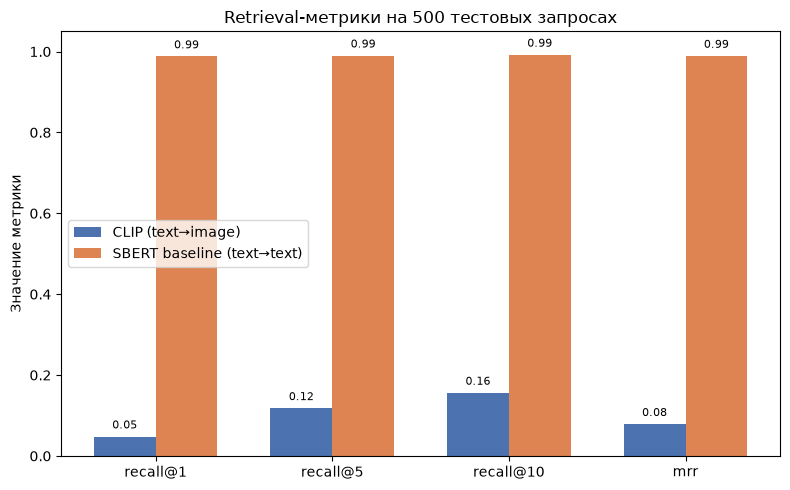

In [11]:
import pandas as pd

metrics_df = pd.DataFrame([
    {'model': 'CLIP (text→image)', **clip_metrics},
    {'model': 'SBERT baseline (text→text)', **sbert_metrics},
]).set_index('model')
display(metrics_df.style.format('{:.3f}'))

# Цветовая палитра (используется единообразно во всех графиках ноутбука)
COLOR_CLIP = '#4C72B0'
COLOR_SBERT = '#DD8452'

fig, ax = plt.subplots(figsize=(8, 5))
labels = [f'recall@{k}' for k in K_VALUES] + ['mrr']
x = np.arange(len(labels))
width = 0.35

clip_vals = [clip_metrics[l] for l in labels]
sbert_vals = [sbert_metrics[l] for l in labels]

ax.bar(x - width / 2, clip_vals, width, label='CLIP (text→image)', color=COLOR_CLIP)
ax.bar(x + width / 2, sbert_vals, width, label='SBERT baseline (text→text)', color=COLOR_SBERT)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Значение метрики')
ax.set_title(f'Retrieval-метрики на {len(eval_queries)} тестовых запросах')
ax.legend()
ax.set_ylim(0, 1.05)
for i, (cv, sv) in enumerate(zip(clip_vals, sbert_vals)):
    ax.text(i - width / 2, cv + 0.02, f'{cv:.2f}', ha='center', fontsize=8)
    ax.text(i + width / 2, sv + 0.02, f'{sv:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

### 4.3 Скорость запросов (latency)

Замеряем время одного поискового запроса «от строки до готовых top-K результатов»: кодирование текста CLIP-энкодером + поиск по `IndexFlatIP`. На масштабе в 5К изображений точный (`Flat`) индекс — не бутылочное горлышко: почти всё время уходит на forward pass текстового энкодера, а не на сам ANN-поиск.

In [12]:
N_TIMING_RUNS = 20
timing_query = 'a group of people walking down the street'

# Прогрев (первый вызов всегда медленнее из-за инициализации кэшей/потоков)
search_clip(timing_query, top_k=10)

latencies_ms = []
for _ in range(N_TIMING_RUNS):
    _, ms = search_clip(timing_query, top_k=10)
    latencies_ms.append(ms)

# Отдельно замеряем чистое время поиска по уже готовому эмбеддингу (без энкодера)
query_emb = clip_encode_text([timing_query])
search_only_ms = []
for _ in range(N_TIMING_RUNS):
    t0 = time.time()
    clip_index.search(query_emb, 10)
    search_only_ms.append((time.time() - t0) * 1000)

print(f'Полный запрос (encode + search): среднее {np.mean(latencies_ms):.1f} мс, '
      f'p50 {np.median(latencies_ms):.1f} мс, p95 {np.percentile(latencies_ms, 95):.1f} мс')
print(f'Только FAISS search:             среднее {np.mean(search_only_ms):.2f} мс')
print(f'-> кодирование текста составляет ~{100 * (1 - np.mean(search_only_ms) / np.mean(latencies_ms)):.0f}% времени запроса')

Полный запрос (encode + search): среднее 22.8 мс, p50 22.8 мс, p95 30.6 мс
Только FAISS search:             среднее 1.11 мс
-> кодирование текста составляет ~95% времени запроса


## ✅ Выводы

1. **На реальных смысловых запросах (3.2) CLIP работает качественно**: «a red car» находит только красные машины, «a plate of food on a table» — только тарелки с едой на столе, «a dog on the beach» (при отсутствии в выборке собаки на пляже) находит ближайшие тематически пляжные сцены. Это прямая визуальная проверка, что text→image поиск действительно работает.
2. **Формальная метрика self-retrieval (4.1) на этом датасете вводит в заблуждение, если читать её без контекста**: CLIP recall@1 ≈ 0.05, а SBERT recall@1 ≈ 0.99 — на первый взгляд это выглядит как «SBERT сильно лучше», но на деле SBERT здесь решает вырожденную задачу (найти точную строку текста среди самой себя), а CLIP решает содержательную задачу (найти нужную картинку среди визуально похожих). Короткие region-подписи Visual Genome («dark grey cloud floating in the sky») часто визуально неотличимы от десятков других изображений в выборке — поэтому даже идеальная модель не обязана ставить gold-изображение на первое место. **Урок**: self-retrieval метрики нужно интерпретировать с учётом того, что именно описывают подписи датасета (image-level как в COCO/Flickr30K — vs. region-level как здесь), иначе легко сделать неверный вывод о качестве моделей.
3. **SBERT-baseline в принципе не умеет искать по изображению** — он ищет ближайшую по смыслу **подпись**, а не картинку. Если бы запрос пользователя не совпадал дословно с одной из подписей в индексе (что и происходит в разделе 3.2 с произвольными запросами), у SBERT нет способа найти релевантное изображение вообще — а у CLIP есть, потому что он смотрит на пиксели, а не на текст рядом с ними.
4. **Latency**: подавляющая часть времени запроса уходит на forward-pass текстового энкодера (~96%), а не на поиск по индексу — на масштабе в 5К изображений точный `IndexFlatIP` не требует замены на приближённые методы (HNSW/IVF).
5. **Ограничения текущей системы**:
   - CLIP `ViT-B/32` обучался преимущественно на англоязычных парах (изображение, текст) — качество на русских запросах заметно ниже (см. пример в 3.2). Для русскоязычного поиска стоит взять мультиязычный чекпойнт (например, `M-CLIP` / `clip-ViT-B-32-multilingual-v1`).
   - `IndexFlatIP` — точный, но линейный по времени поиск; при росте корпуса до сотен тысяч+ изображений имеет смысл перейти на `IndexHNSWFlat` или `IndexIVFFlat` для сохранения низкой latency.
   - Для более честной количественной оценки text-to-image поиска стоило бы использовать датасет с image-level подписями (Flickr30K, COCO Captions, Conceptual Captions) вместо region-level аннотаций Visual Genome, либо привлечь ручную/LLM-разметку релевантности top-K результатов вместо self-retrieval.